# 03. Deep Learning Model (PyTorch LSTM)
이 노트북에서는 1차 필터링된 이상 로그들의 맥락적 흐름(Sequence)을 PyTorch LSTM 신경망에 적용하여 최종 에러 등급(ALERT, FATAL, WARNING)으로 다중 분류하는 딥러닝 모델을 훈련합니다.

In [ ]:
# %pip install torch

In [1]:
%load_ext autoreload
%autoreload 2


import os
import sys
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix

# 프로젝트 루트 경로를 sys.path에 추가하여 src 패키지를 찾을 수 있도록 함
sys.path.append(os.path.abspath(os.path.join("..")))

from src.parser import LogParser
from src.classifier import LSTMClassifier, train_model

# 한글 폰트 설정 (추가됨)
import platform

if platform.system() == "Darwin":  # Mac
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":  # Windows
    plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False


## 1. 데이터 로드 및 정제

In [4]:
SSD_PATH = "/Volumes/T7/LogSentinel_Data/raw/"
LOCAL_PATH = os.path.abspath(os.path.join("..", "data", "raw"))

def get_data_path(filename):
    ssd_file = os.path.join(SSD_PATH, filename)
    local_file = os.path.join(LOCAL_PATH, filename)
    if os.path.exists(ssd_file):
        return ssd_file
    return local_file

# 프로토타입(BGL_2k.log) 대신, 스마트 샘플링된 고농축 균형 데이터셋(BGL_balanced.log)을 로드합니다.
# - 원본 정상 로그 수: 4,399,503개 ➔ **80,000개 랜덤 샘플링**
# - 원본 장애 로그 수: 348,460개   ➔ **348,460개 전량 확보 (필터링 방지)**
# - 최종 병합 셔플 "BGL_balanced.log" 행수: **총 428,460개 행**
log_file_path = get_data_path("BGL_balanced.log")

data = []
print(f"데이터셋 로딩 및 파싱 중: {log_file_path}")
with open(log_file_path, "r", encoding="utf-8") as f:
    for idx, line in enumerate(f):
        parts = line.strip().split()
        if len(parts) < 10:
            continue
        level = parts[8]
        raw_message = " ".join(parts[9:])
        data.append({"level": level, "raw_message": raw_message})
        
        if (idx + 1) % 100000 == 0:
            print(f".. {idx + 1} 행 로드 완료 ..")

df = pd.DataFrame(data)
print(f"Successfully Loaded {len(df)} logs.")
print("Original Level counts:\n", df["level"].value_counts())

데이터셋 로딩 및 파싱 중: /Users/soromiso/Desktop/Dev/soromiso/LogSentinel/data/raw/BGL_balanced.log
.. 100000 행 로드 완료 ..
.. 200000 행 로드 완료 ..
.. 300000 행 로드 완료 ..
.. 400000 행 로드 완료 ..
Successfully Loaded 427832 logs.
Original Level counts:
 level
FATAL      357679
INFO        67156
ERROR        2126
WARNING       432
SEVERE        343
FAILURE        89
Kill            7
Name: count, dtype: int64


## 2. 다중 클래스 라벨 매핑 및 TF-IDF 피처 벡터화

In [5]:
# 로그 레벨을 3개 클래스로 매핑
# INFO -> 0
# FATAL / SEVERE -> 1
# ERROR / WARNING -> 2
def map_level_to_class(level):
    level_upper = level.upper()
    if level_upper == "INFO":
        return 0
    elif level_upper in ["FATAL", "SEVERE"]:
        return 1
    elif level_upper in ["ERROR", "WARNING"]:
        return 2
    return 0  # fallback

df["class"] = df["level"].apply(map_level_to_class)
print("Mapped Class counts: \n", df["class"].value_counts().to_dict())

# LogParser 불러와 데이터 TF-IDF 변환
parser = LogParser(max_features=500)
df["cleaned_message"] = df["raw_message"].apply(parser.clean_log)
X = parser.fit_transform(df["cleaned_message"])
y = df["class"].values
print("TF-IDF Matrix Shape:", X.shape)

Mapped Class counts: 
 {1: 358022, 0: 67252, 2: 2558}
TF-IDF Matrix Shape: (427832, 500)


## 3. 슬라이딩 윈도우 시퀀스 데이터셋 구축

In [6]:
def create_sequences(X_data, y_data, seq_length=10):
    X_seq = []
    y_seq = []
    for i in range(len(X_data) - seq_length + 1):
        X_seq.append(X_data[i : i + seq_length])
        # 시퀀스의 마지막 로그 레벨을 타겟 클래스로 설정
        y_seq.append(y_data[i + seq_length - 1])
    return np.array(X_seq, dtype=np.float32), np.array(y_seq, dtype=np.int64)

SEQUENCE_LENGTH = 10
X_sequence, y_sequence = create_sequences(X, y, seq_length=SEQUENCE_LENGTH)
print("Sequences X shape:", X_sequence.shape)
print("Sequences y shape:", y_sequence.shape)

# PyTorch DataLoader 구축
# 훈련/테스트 데이터셋 분리 (시간 순으로 분할)
split_idx = int(len(X_sequence) * 0.8)

X_train, X_test = X_sequence[:split_idx], X_sequence[split_idx:]
y_train, y_test = y_sequence[:split_idx], y_sequence[split_idx:]

train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long))

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")

Sequences X shape: (427823, 10, 500)
Sequences y shape: (427823,)
Train batches: 10696, Test batches: 2674


## 4. LSTM Classifier 모델 정의 및 훈련

In [7]:
import importlib
import src.classifier
importlib.reload(src.classifier)
from src.classifier import LSTMClassifier, train_model
from sklearn.utils.class_weight import compute_class_weight

device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print("Using device:", device)

# 클래스 불균형 극복을 위한 클래스별 가중치(Class Weight) 계산
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
print("Calculated Class Weights:", class_weights)

# 모델 초기화
input_dim = 500   # TF-IDF max_features
hidden_dim = 64
num_classes = 3
num_layers = 2

model = LSTMClassifier(input_dim=input_dim, hidden_dim=hidden_dim, num_classes=num_classes, num_layers=num_layers)

# 손실 함수(CrossEntropyLoss)에 가중치 텐서 반영
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# train_model 함수 호출을 통한 모델 학습 진행 및 히스토리 반환
EPOCHS = 10
history = train_model(
    model=model,
    train_loader=train_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=EPOCHS,
    device=device
)



Using device: mps
Calculated Class Weights: [ 2.1218986   0.39828239 55.7332682 ]
Epoch 1/10 - Loss: 0.0343 Acc: 0.9885
Epoch 2/10 - Loss: 0.0117 Acc: 0.9940
Epoch 3/10 - Loss: 0.0112 Acc: 0.9945
Epoch 4/10 - Loss: 0.0113 Acc: 0.9945
Epoch 5/10 - Loss: 0.0109 Acc: 0.9945
Epoch 6/10 - Loss: 0.0099 Acc: 0.9947
Epoch 7/10 - Loss: 0.0110 Acc: 0.9950
Epoch 8/10 - Loss: 0.0106 Acc: 0.9951
Epoch 9/10 - Loss: 0.0106 Acc: 0.9951
Epoch 10/10 - Loss: 0.0097 Acc: 0.9953


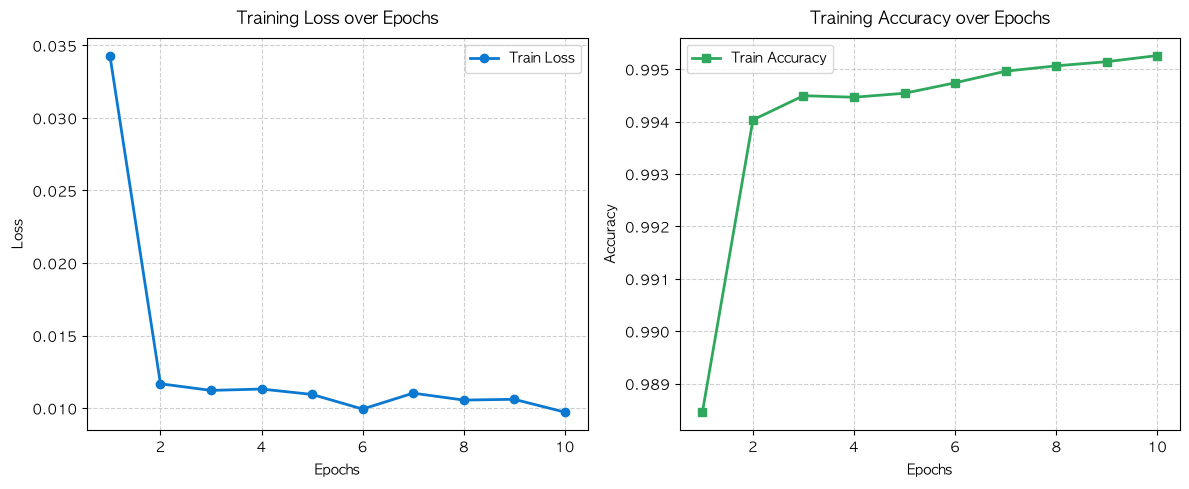

In [8]:
# 훈련 손실(Loss) 및 정확도(Accuracy) 시각화
epochs_range = range(1, EPOCHS + 1)
plt.figure(figsize=(12, 5))

# Loss 그래프 (Brand Blue #0B79D0 적용)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["loss"], marker='o', label='Train Loss', color='#0B79D0', linewidth=2)
plt.title('Training Loss over Epochs', fontsize=12, pad=10)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Accuracy 그래프 (Brand Green #2FA85D 적용)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["acc"], marker='s', label='Train Accuracy', color='#2FA85D', linewidth=2)
plt.title('Training Accuracy over Epochs', fontsize=12, pad=10)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

## 5. 모델 평가 및 성능 지표 출력

In [9]:
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device).float()
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().tolist())
        all_targets.extend(labels.tolist())

# 결과 출력
cm = confusion_matrix(all_targets, all_preds)
print("=== Confusion Matrix ===")
print(cm)

print("\n=== Classification Report ===")
print(classification_report(all_targets, all_preds, target_names=["INFO", "FATAL/SEVERE", "ERROR/WARNING"], zero_division=0))


=== Confusion Matrix ===
[[13401    39    44]
 [  364 71200     6]
 [    0     0   511]]

=== Classification Report ===
               precision    recall  f1-score   support

         INFO       0.97      0.99      0.98     13484
 FATAL/SEVERE       1.00      0.99      1.00     71570
ERROR/WARNING       0.91      1.00      0.95       511

     accuracy                           0.99     85565
    macro avg       0.96      1.00      0.98     85565
 weighted avg       0.99      0.99      0.99     85565



findfont: Failed to find font weight bold, now using 400.


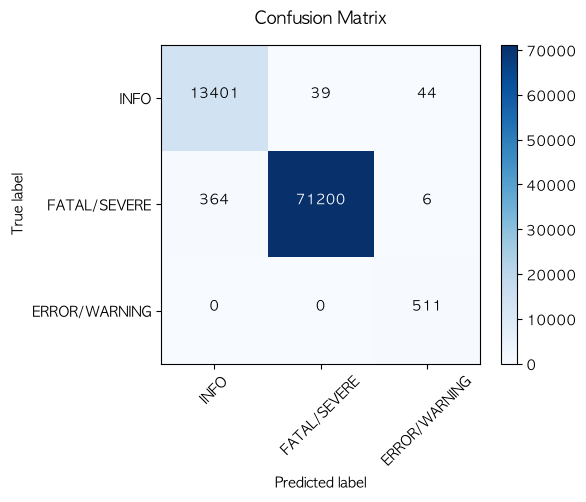

In [10]:
# Confusion Matrix 시각화
classes = ["INFO", "FATAL/SEVERE", "ERROR/WARNING"]
plt.figure(figsize=(6, 5))
im = plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix', fontsize=12, fontweight='bold', pad=15)
plt.colorbar(im)
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

# 오차 행렬 내 텍스트 삽입
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

## 6. 모델 및 벡터라이저 저장
훈련이 완료된 `LSTMClassifier` 모델 가중치와 입력 텍스트를 수치 벡터로 변환하는 데 사용된 `LogParser` (TfidfVectorizer) 객체를 `models/` 디렉토리에 저장합니다.

In [11]:
# 외장 SSD T7 마운트 경로 우선 확인, 없으면 로컬 fallback
EXTERNAL_SSD_PATH = "/Volumes/T7/LogSentinel_Data/"
LOCAL_MODEL_DIR = "../models"

if os.path.exists(EXTERNAL_SSD_PATH):
    model_dir = os.path.join(EXTERNAL_SSD_PATH, "models")
    print(f"[경로 설정] 외장 SSD 마운트 감지됨. 저장 경로: {model_dir}")
else:
    model_dir = LOCAL_MODEL_DIR
    print(f"[경로 설정] 외장 SSD 미마운트. 로컬 저장 경로: {model_dir}")

os.makedirs(model_dir, exist_ok=True)

# 1. LogParser (벡터라이저) 저장
vectorizer_path = os.path.join(model_dir, "vectorizer.pkl")
parser.save_vectorizer(vectorizer_path)
print(f"LogParser vectorizer saved to {vectorizer_path}")

# 2. LSTM Classifier 모델 가중치 저장
model_path = os.path.join(model_dir, "lstm_model.pth")
torch.save(model.state_dict(), model_path)
print(f"LSTM model weights saved to {model_path}")

[경로 설정] 외장 SSD 미마운트. 로컬 저장 경로: ../models
LogParser vectorizer saved to ../models/vectorizer.pkl
LSTM model weights saved to ../models/lstm_model.pth
